# AI Data Analysis Assistant (Jupyter Notebook)
*Complete solution for Hackathon 2026*

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output
import io
%matplotlib inline

In [3]:
# Generate sample dataset (100 rows)
def generate_sample_data():
    np.random.seed(42)
    categories = ['Electronics', 'Clothing', 'Books', 'Home', 'Toys']
    cities = ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix']
    data = {
        'Product': [f'Product {i}' for i in range(1, 101)],
        'Category': np.random.choice(categories, 100),
        'Sales': np.random.randint(200, 2000, 100),
        'Quantity': np.random.randint(1, 50, 100),
        'City': np.random.choice(cities, 100),
        'Customer_Age': np.random.randint(18, 70, 100)
    }
    return pd.DataFrame(data)

df = generate_sample_data()
print("Sample Data Loaded! (100 rows)")
display(df.head())

Sample Data Loaded! (100 rows)


,Product,Category,Sales,Quantity,City,Customer_Age
0,Product 1,Home,1251,49,New York,59
1,Product 2,Toys,334,49,Chicago,23
2,Product 3,Books,400,12,New York,32
3,Product 4,Toys,979,39,Phoenix,60
4,Product 5,Toys,1129,2,Los Angeles,54


In [4]:
# Dataset Overview
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"Missing Values: {df.isnull().sum().sum()}")
print("\nData Types:")
print(df.dtypes)

Rows: 100, Columns: 6
Missing Values: 0

Data Types:
Product         object
Category        object
Sales            int32
Quantity         int32
City            object
Customer_Age     int32
dtype: object


In [5]:
# Descriptive Statistics
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Sales,100.0,1245.70,473.336012,295.0,859.25,1253.5,1645.25,1992.0
Quantity,100.0,24.65,15.193948,1.0,11.00,24.5,37.00,49.0
Customer_Age,100.0,43.81,15.356830,18.0,31.75,45.0,56.00,69.0


In [6]:
# Q&A Engine (Rule-based)
def answer_question(df, q):
    q = q.lower()
    if 'highest sales' in q or 'max sales' in q:
        if 'Sales' in df.columns:
            row = df.loc[df['Sales'].idxmax()]
            return f"Product **{row['Product']}** had the highest sales of {row['Sales']} in {row['City']}."
    if 'average age' in q:
        if 'Customer_Age' in df.columns:
            avg = df['Customer_Age'].mean()
            return f"Average customer age is **{avg:.1f}** years."
    if 'maximum orders' in q or 'city with max orders' in q:
        if 'City' in df.columns:
            city = df['City'].value_counts().idxmax()
            count = df['City'].value_counts().max()
            return f"**{city}** has maximum orders ({count})."
    if 'category appears most' in q or 'most frequent category' in q:
        if 'Category' in df.columns:
            cat = df['Category'].value_counts().idxmax()
            cnt = df['Category'].value_counts().max()
            return f"**{cat}** appears most frequently ({cnt} times)."
    return "Sorry, couldn't parse that question."

In [7]:
# Judge Questions
questions = [
    "Which product generated the highest sales?",
    "What is the average age of customers?",
    "Which city has the maximum orders?",
    "Which category appears most frequently?"
]

for i, q in enumerate(questions):
    print(f"Q{i+1}: {q}")
    print(f"A: {answer_question(df, q)}\n")

Q1: Which product generated the highest sales?
A: Product **Product 22** had the highest sales of 1992 in Chicago.

Q2: What is the average age of customers?
A: Average customer age is **43.8** years.

Q3: Which city has the maximum orders?
A: **New York** has maximum orders (24).

Q4: Which category appears most frequently?
A: **Home** appears most frequently (26 times).



In [8]:
# Ask your own question
custom = input("Type your question: ")
if custom:
    print(f"Q: {custom}")
    print(f"A: {answer_question(df, custom)}")

Type your question:  Which product generated the highest sales?


Q: Which product generated the highest sales?
A: Product **Product 22** had the highest sales of 1992 in Chicago.


In [9]:
# Chart Generator
def plot_chart(df, chart_type):
    fig, ax = plt.subplots(figsize=(10,5))
    if chart_type == 'Bar':
        counts = df['Category'].value_counts()
        sns.barplot(x=counts.index, y=counts.values, palette='viridis', ax=ax)
        ax.set_title('Category Distribution', fontsize=14)
        ax.set_xlabel('Category'); ax.set_ylabel('Count')
    elif chart_type == 'Pie':
        counts = df['Category'].value_counts()
        ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
        ax.set_title('Category Distribution (Pie)')
    elif chart_type == 'Hist':
        ax.hist(df['Sales'], bins=20, edgecolor='black', alpha=0.7, color='#6c8cff')
        ax.set_title('Sales Distribution')
        ax.set_xlabel('Sales'); ax.set_ylabel('Frequency')
    elif chart_type == 'Scatter':
        scatter = ax.scatter(df['Sales'], df['Quantity'], 
                             c=df['Category'].astype('category').cat.codes, cmap='Set2')
        ax.set_xlabel('Sales'); ax.set_ylabel('Quantity')
        ax.set_title('Sales vs Quantity')
    plt.tight_layout()
    plt.show()

Bar Chart


C:\Users\Abdulah\AppData\Local\Temp\ipykernel_13280\1655682188.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis', ax=ax)


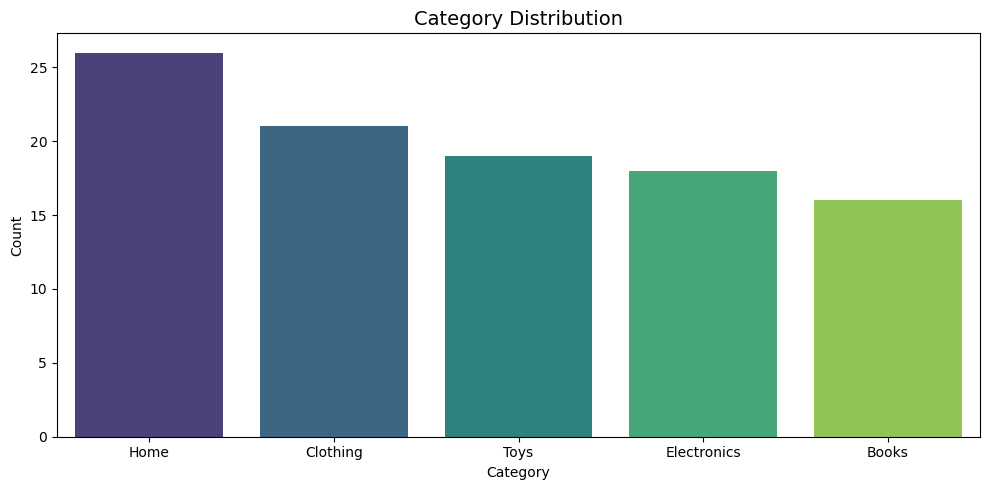

 Pie Chart


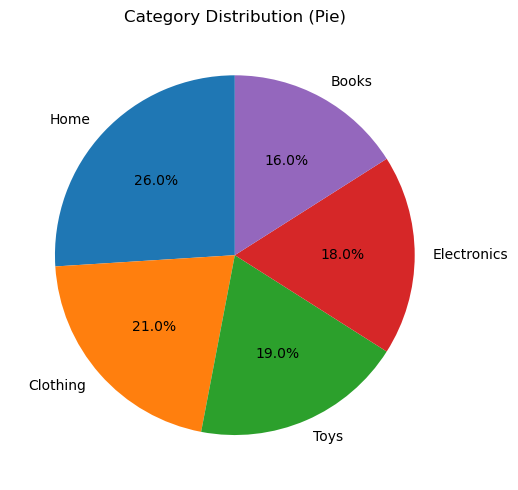

Histogram


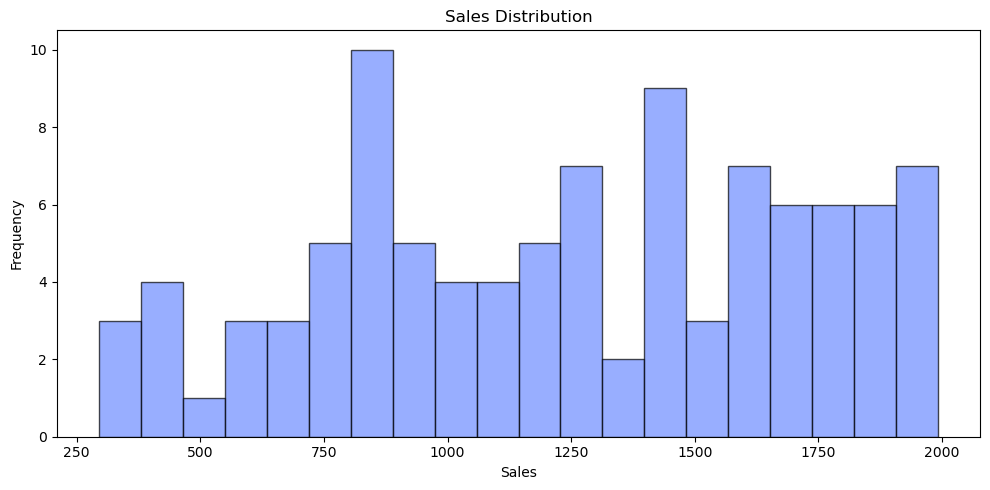

Scatter Plot


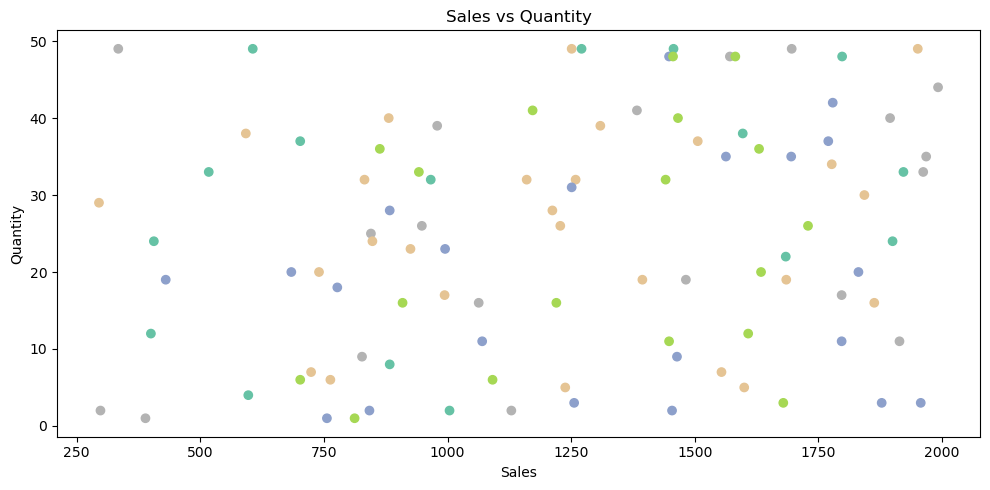

In [10]:
# Generate all 4 charts
print("Bar Chart")
plot_chart(df, 'Bar')
print(" Pie Chart")
plot_chart(df, 'Pie')
print("Histogram")
plot_chart(df, 'Hist')
print("Scatter Plot")
plot_chart(df, 'Scatter')

In [11]:
# AI Explanation (fallback template)
def get_explanation(df, chart_type='Bar'):
    if chart_type == 'Bar' and 'Category' in df.columns:
        top = df['Category'].value_counts().idxmax()
        pct = (df['Category'].value_counts().max() / len(df)) * 100
        return f"The **{top}** category has the highest frequency, accounting for approximately {pct:.1f}% of the total records."
    return "This chart provides a visual summary of the dataset."

print("Explanation for Bar Chart:")
print(get_explanation(df))

Explanation for Bar Chart:
The **Home** category has the highest frequency, accounting for approximately 26.0% of the total records.
